# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Muhammad Zaki Nanda Wahyudi              |5054251007       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [17]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from IPython.display import display



In [18]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv("WineQT.csv")

print("========== Ukuran Dataset ==========")
print(f"Jumlah Baris: {data.shape[0]}, Jumlah Kolom: {data.shape[1]}")

print("\n\n========== 5 Baris Pertama ==========")
display(data.head())

print("\n\n========== 5 Baris Terakhir ==========")
display(data.tail())

print("\n\n========== Informasi Dataset ==========")
data.info()
print("Berdasarkan data diatas, dapat kita simpulkan bahwa tidak ada missing value karena jumlah non-null selalu sama")

print("\n\n========== Pembersihan Data ==========")
print(f"Jumlah Baris Duplikat: {data.duplicated().sum()}")

data = data.drop(columns=["Id"])
print("Kolom Id berhasil dihapus karena tidak berfungsi untuk pemodelan")

print("\n\n========== Statistik Deskriptif ==========")
display(data.describe())

print("\n\n========== Persebaran Variabel Target (Quality) ==========")
print(data["quality"].value_counts().sort_index())
print("Data memiliki persebaran yang tidak seimbang, di mana sebagian besar sampel berada pada rentang kualitas 5 dan 6")

========== Ukuran Dataset ==========
Jumlah Baris: 1143, Jumlah Kolom: 13


========== 5 Baris Pertama ==========


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4




========== 5 Baris Terakhir ==========


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597




========== Informasi Dataset ==========
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Berdasarkan data diatas, dapat kita simpulka

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000




========== Persebaran Variabel Target (Quality) ==========
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64
Data memiliki persebaran yang tidak seimbang, di mana sebagian besar sampel berada pada rentang kualitas 5 dan 6


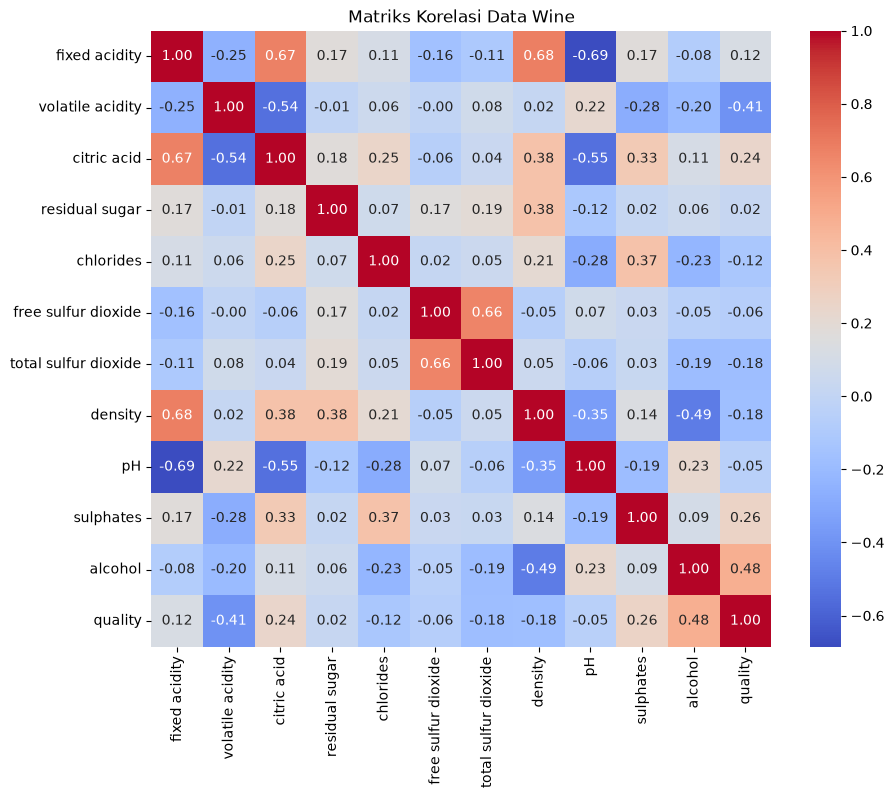

Dari matriks korelasi tersebut, fitur 'Alkohol' memiliki korelasi positif paling kuat terhadap kualitas wine, sedangkan 'Volatile acidity' memiliki korelasi negatif paling kuat


In [19]:
# Tampilkan Korelasi Matrix
korelasi = data.corr()

plt.figure(figsize = (10, 8))
sns.heatmap(korelasi, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Matriks Korelasi Data Wine")
plt.show()

print("Dari matriks korelasi tersebut, fitur 'Alkohol' memiliki korelasi positif paling kuat terhadap kualitas wine, sedangkan 'Volatile acidity' memiliki korelasi negatif paling kuat")

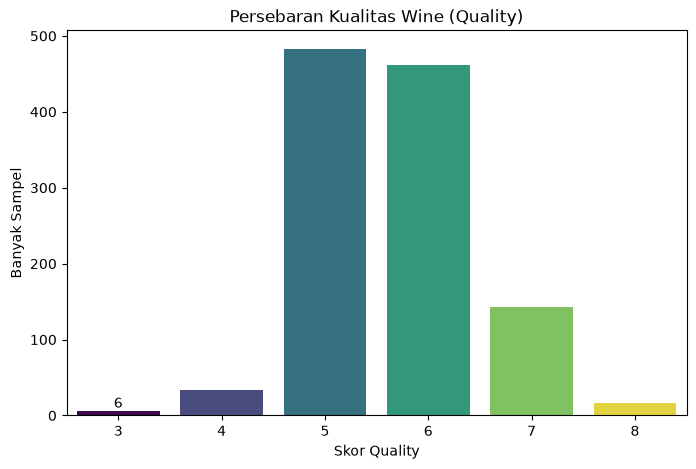

Visualisasi di atas menunjukkan persebaran data yang tidak seimbang, di mana batang terbanyak didominasi oleh wine dengan skor kualitas 5 dan 6


In [20]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize = (8, 5))

ax = sns.countplot(data = data, x = "quality", hue = "quality", palette = "viridis", legend = False)

plt.title("Persebaran Kualitas Wine (Quality)")
plt.xlabel("Skor Quality")
plt.ylabel("Banyak Sampel")

ax.bar_label(ax.containers[0])

plt.show()

print("Visualisasi di atas menunjukkan persebaran data yang tidak seimbang, di mana batang terbanyak didominasi oleh wine dengan skor kualitas 5 dan 6")

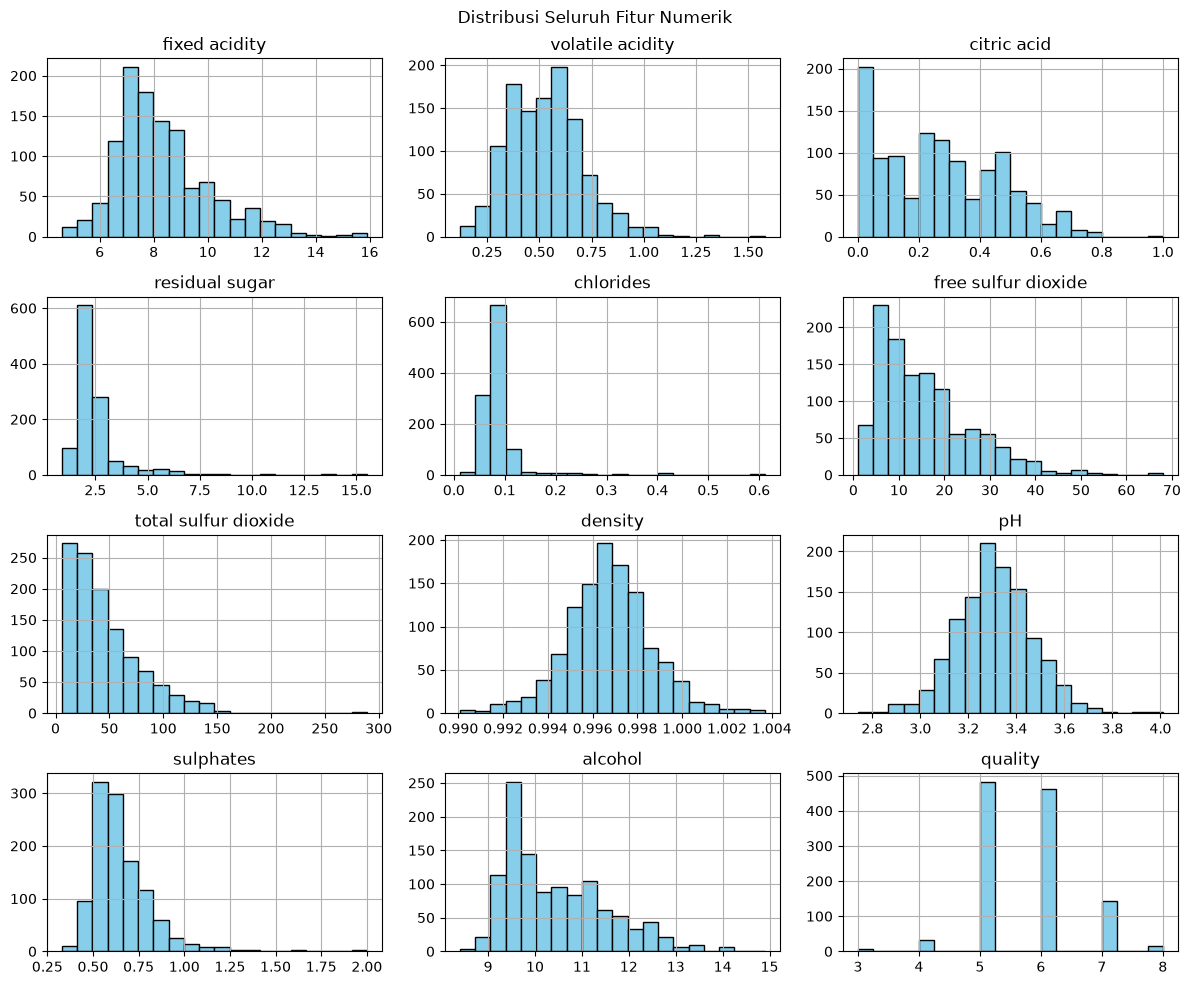

In [21]:
data.hist(figsize = (12, 10), bins = 20, color = "skyblue", edgecolor = "black")
plt.suptitle("Distribusi Seluruh Fitur Numerik")
plt.tight_layout()
plt.show()

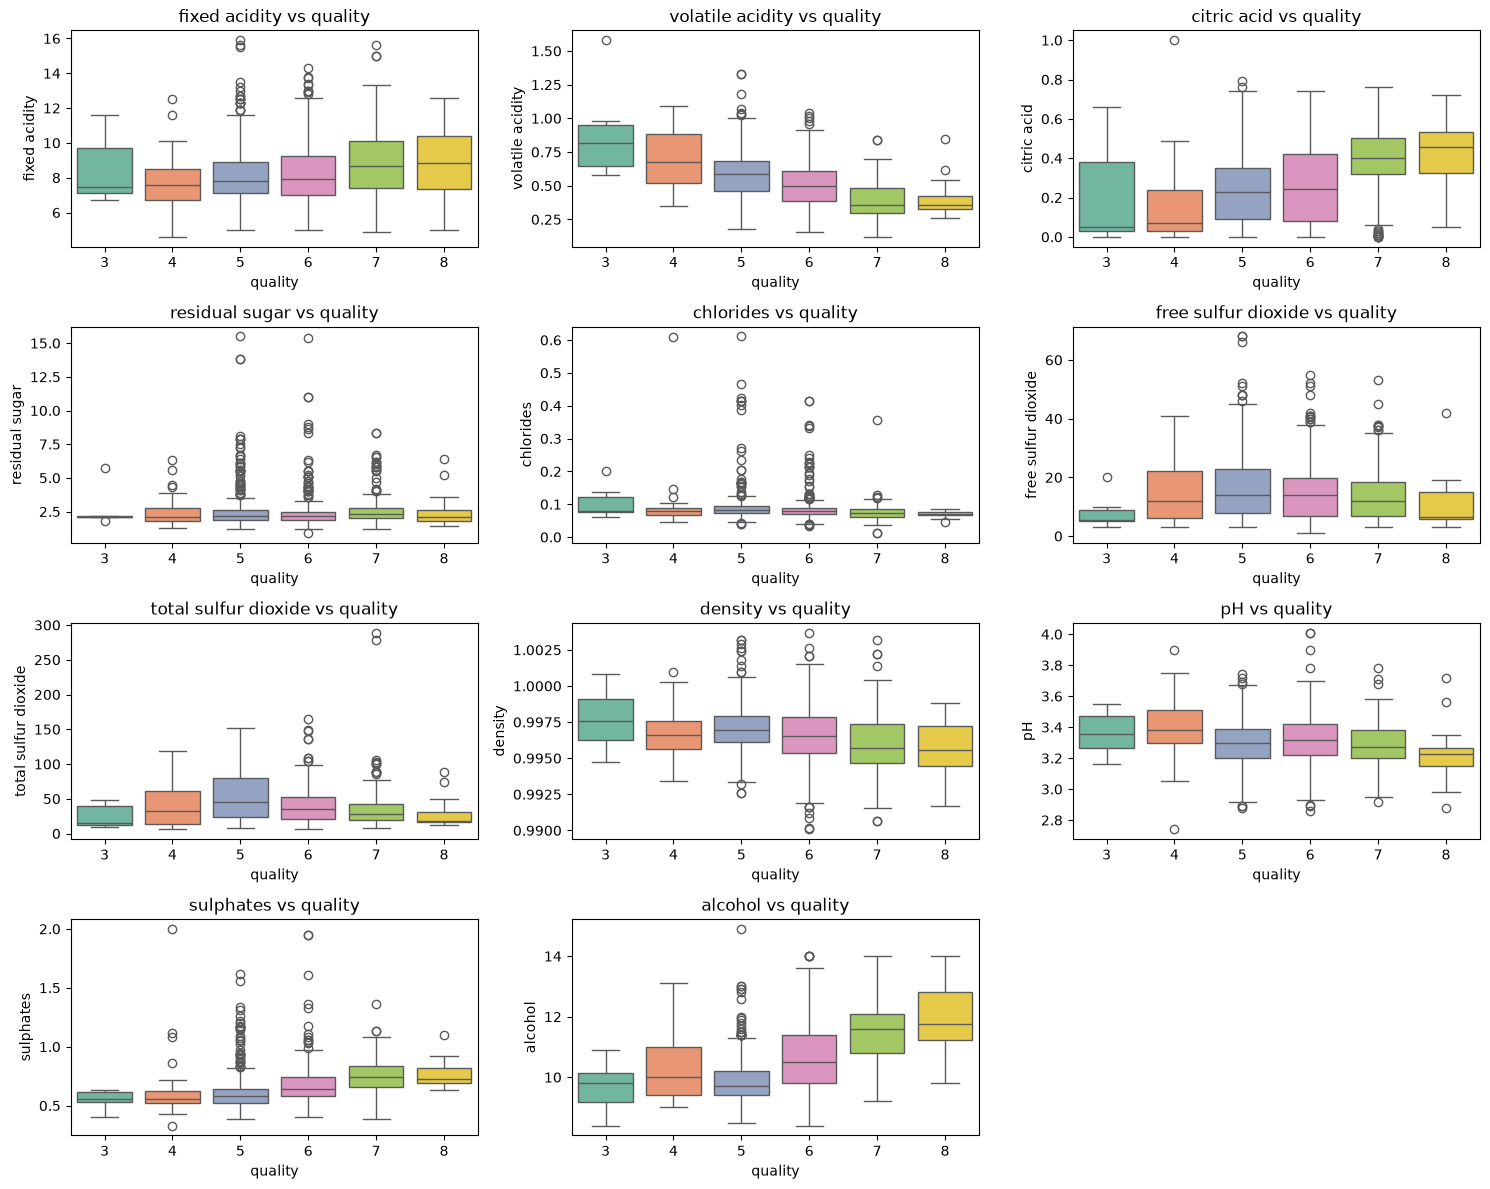

In [22]:
features = data.drop(columns = ["quality"]).columns

plt.figure(figsize = (15, 12))

for i, col in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data = data, x = "quality", y = col, hue = "quality", palette = "Set2", legend = False)
    plt.title(f"{col} vs quality")

plt.tight_layout()
plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [23]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
print("Berdasarkan eksplorasi awal, dataset tidak memiliki missing values (NaN) maupun data duplikat")
print("Sehingga tidak diperlukan langkah penanganan drop atau imputasi data")
print("Dataset bersih dari missing values (NaN) dan data duplikat")

Berdasarkan eksplorasi awal, dataset tidak memiliki missing values (NaN) maupun data duplikat
Sehingga tidak diperlukan langkah penanganan drop atau imputasi data
Dataset bersih dari missing values (NaN) dan data duplikat


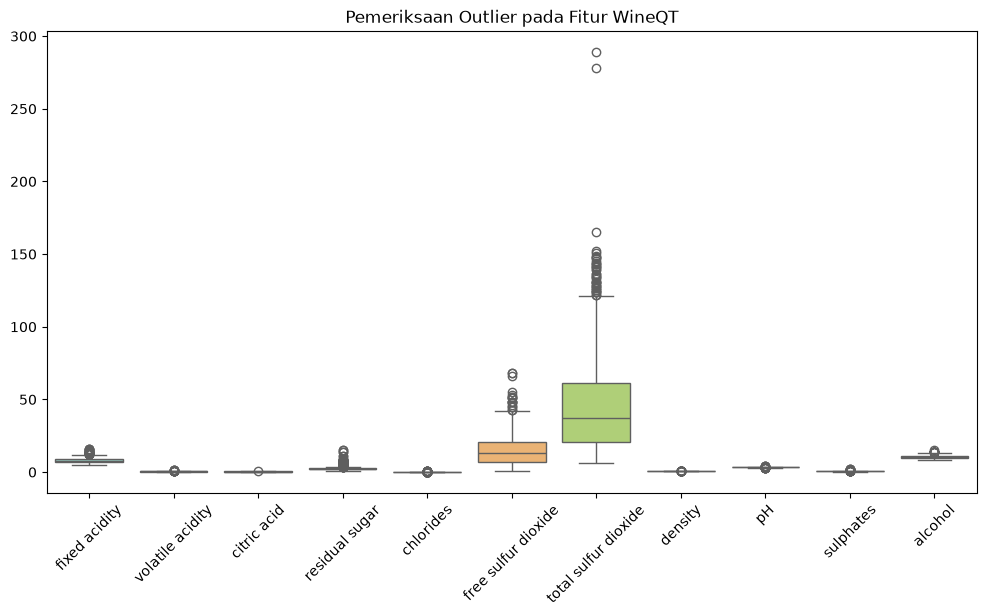

Jumlah baris dengan outlier: 1143
Jumlah baris tanpa outlier: 848


In [24]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
plt.figure(figsize = (12, 6))
sns.boxplot(data = data.drop(columns = ["quality"]), palette = "Set3")
plt.xticks(rotation = 45)
plt.title("Pemeriksaan Outlier pada Fitur WineQT")
plt.show()

def remove_outliers_iqr(df, target_col = 'quality'):
    features = df.drop(columns = [target_col]).columns
    Q1 = df[features].quantile(0.25)
    Q3 = df[features].quantile(0.75)
    IQR = Q3 - Q1

    condition = ~((df[features] < (Q1 - 1.5 * IQR)) | (df[features] > (Q3 + 1.5 * IQR))).any(axis = 1)
    return df[condition].reset_index(drop = True)

data_with_outliers = data.copy()
data_without_outliers = remove_outliers_iqr(data)

print(f"Jumlah baris dengan outlier: {len(data_with_outliers)}")
print(f"Jumlah baris tanpa outlier: {len(data_without_outliers)}")

In [25]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

# 1. PEMISAHAN X DAN y SERTA TRAIN-TEST SPLIT
# Skenario A
X_with = data_with_outliers.drop(columns = ["quality"])
y_with = data_with_outliers["quality"]

X_train_with, X_test_with, y_train_with, y_test_with = train_test_split(X_with, y_with, test_size = 0.2, random_state = 42, stratify = y_with)

# Skenario B
X_without = data_without_outliers.drop(columns = ["quality"])
y_without = data_without_outliers["quality"]

X_train_without, X_test_without, y_train_without, y_test_without = train_test_split(X_without, y_without, test_size = 0.2, random_state = 42, stratify = y_without)

# 2. Feature Scaling
# Skaling untuk data dengan outlier
scaler_with = StandardScaler()
X_train_with_scaled = scaler_with.fit_transform(X_train_with)
X_test_with_scaled = scaler_with.transform(X_test_with)

# Skaling untuk data tanpa outlier
scaler_without = StandardScaler()
X_train_without_scaled = scaler_without.fit_transform(X_train_without)
X_test_without_scaled = scaler_without.transform(X_test_without)

# 3. Skenario data
datasets = {
    "1. Dengan Outlier - Tanpa scaling": (X_train_with, X_test_with, y_train_with, y_test_with),
    "2. Dengan Outlier - Dengan Scaling": (X_train_with_scaled, X_test_with_scaled, y_train_with, y_test_with),
    "3. Tanpa Outlier - Tanpa Scaling": (X_train_without, X_test_without, y_train_without, y_test_without),
    "4. Tanpa Outlier - Dengan Scaling": (X_train_without_scaled, X_test_without_scaled, y_train_without, y_test_without)
}

print("4 Skenarion Preprocessing Berhasil Disiapkan!")
for name in datasets.keys():
    print(f"- {name}")

4 Skenarion Preprocessing Berhasil Disiapkan!
- 1. Dengan Outlier - Tanpa scaling
- 2. Dengan Outlier - Dengan Scaling
- 3. Tanpa Outlier - Tanpa Scaling
- 4. Tanpa Outlier - Dengan Scaling


# 3. Eksperimen Model KNN


In [26]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

k_values = [1, 3, 5, 7, 9, 11]
weight_options = ["uniform", "distance"]
p_values = [1, 2]

results = []

for scenario_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    for k in k_values:
        for w in weight_options:
            for p_val in p_values:
                knn = KNeighborsClassifier(
                    n_neighbors = k,
                    weights = w,
                    metric = "minkowski",
                    p = p_val
                )
                knn.fit(X_tr, y_tr)

                pred_train = knn.predict(X_tr)
                pred_test = knn.predict(X_te)

                acc_train = accuracy_score(y_tr, pred_train)
                acc_test = accuracy_score(y_te, pred_test)
                f1_test = f1_score(y_te, pred_test, average = "macro", zero_division = 0)

                results.append({
                    "Skenario Data": scenario_name,
                    "k": k,
                    "Weights": w,
                    "Jarak":"Manhattan (p=1)" if p_val == 1 else "Euclidean (p=2)",
                    "Train Acc": round(acc_train, 4),
                    "Test Acc": round(acc_test, 4),
                    "Test Macro F1": round(f1_test, 4)
                })

df_result = pd.DataFrame(results)
df_result.sort_values(by = ["Test Acc", "Test Macro F1"], ascending = False).head(10)


,Skenario Data,k,Weights,Jarak,Train Acc,Test Acc,Test Macro F1
42,2. Dengan Outlier - Dengan Scaling,9,distance,Manhattan (p=1),1.0,0.6987,0.3339
95,4. Tanpa Outlier - Dengan Scaling,11,distance,Euclidean (p=2),1.0,0.6882,0.4466
47,2. Dengan Outlier - Dengan Scaling,11,distance,Euclidean (p=2),1.0,0.6856,0.3298
46,2. Dengan Outlier - Dengan Scaling,11,distance,Manhattan (p=1),1.0,0.6812,0.3296
94,4. Tanpa Outlier - Dengan Scaling,11,distance,Manhattan (p=1),1.0,0.6765,0.4418
43,2. Dengan Outlier - Dengan Scaling,9,distance,Euclidean (p=2),1.0,0.6725,0.3213
91,4. Tanpa Outlier - Dengan Scaling,9,distance,Euclidean (p=2),1.0,0.6647,0.4356
78,4. Tanpa Outlier - Dengan Scaling,3,distance,Manhattan (p=1),1.0,0.6647,0.3757
38,2. Dengan Outlier - Dengan Scaling,7,distance,Manhattan (p=1),1.0,0.6638,0.3204
31,2. Dengan Outlier - Dengan Scaling,3,distance,Euclidean (p=2),1.0,0.6594,0.3513


# 4. Evaluasi Model


         Classification Report Model KNN Terbaik (Index 95)         
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         4
           5       0.74      0.74      0.74        72
           6       0.65      0.74      0.69        72
           7       0.67      0.53      0.59        19
           8       1.00      0.50      0.67         2

    accuracy                           0.69       170
   macro avg       0.51      0.42      0.45       170
weighted avg       0.67      0.69      0.68       170



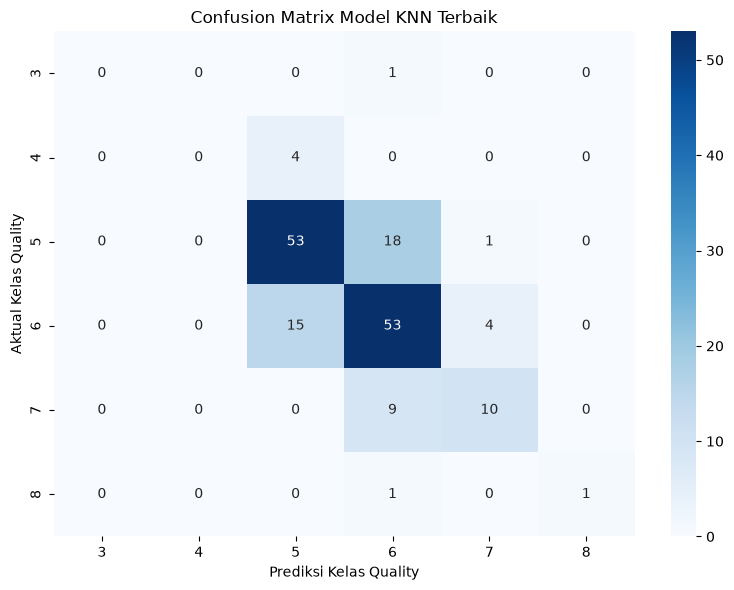

In [27]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

best_knn = KNeighborsClassifier(
    n_neighbors = 11,
    weights = "distance",
    metric = "minkowski",
    p = 2
)

best_knn.fit(X_train_without_scaled, y_train_without)
y_pred = best_knn.predict(X_test_without_scaled)

print("="*65)
print("         Classification Report Model KNN Terbaik (Index 95)         ")
print("="*65)
print(classification_report(y_test_without, y_pred, zero_division = 0))

plt.figure(figsize = (8, 6))
cm = confusion_matrix(y_test_without, y_pred)

sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = sorted(y_test_without.unique()),
    yticklabels = sorted(y_test_without.unique())
)

plt.title("Confusion Matrix Model KNN Terbaik")
plt.xlabel("Prediksi Kelas Quality")
plt.ylabel("Aktual Kelas Quality")
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

## 1. Perbandingan Skenario Eksperimen

Berdasarkan 96 kombinasi percobaan yang telah dijalankan, terdapat beberapa poin utama yang dapat diamati:

* **Pengaruh Feature Scaling:**
* Seluruh posisi 10 teratas didominasi oleh skenario yang **menggunakan *scaling* (`StandardScaler`)**.
* Hal ini terjadi karena algoritma k-NN bekerja berdasarkan perhitungan jarak antarsampel. Jika skala fitur tidak disamakan, fitur yang memiliki rentang nilai besar akan mendominasi perhitungan jarak secara tidak seimbang.


* **Perbandingan Penanganan Outlier (Skenario 2 vs Skenario 4):**
* Secara akurasi murni, **Index 42** (dengan *outlier* + *scaling*) memiliki nilai tertinggi, yaitu **69,87%**. Namun, nilai **Test Macro F1-nya sangat rendah, yaitu hanya 33,39%**.
* Sementara itu, **Index 95** (tanpa *outlier* + *scaling*) memiliki akurasi sebesar **68,82%**, tetapi nilai **Test Macro F1-nya meningkat signifikan menjadi 44,66%**.
* Hal ini menunjukkan bahwa pembersihan *outlier* menggunakan metode IQR berhasil membuat model memprediksi kelas-kelas minoritas secara lebih seimbang.


* **Pengaruh Hyperparameter (k, Weights, dan Jarak):**
* Nilai `Train Acc` bernilai **1,0 (100%)** pada seluruh posisi teratas karena penggunaan parameter **`weights='distance'`**. Pada k-NN berbasis bobot jarak, sampel data latih memiliki jarak $0$ terhadap dirinya sendiri, sehingga akurasi pada data latih selalu bernilai sempurna.
* Nilai **$k=11$** dan **$k=9$** memberikan performa yang lebih stabil dibandingkan nilai $k$ yang kecil.
* Untuk metrik jarak, **Euclidean ($p=2$)** sedikit lebih unggul pada nilai Macro F1 dibandingkan Manhattan ($p=1$) pada skenario tanpa *outlier*.



---

## 2. Analisis Model Terbaik (Index 95)

Konfigurasi pada **Index 95** (*Tanpa Outlier + Dengan Scaling*, $k=11$, `weights='distance'`, $p=2$) dipilih sebagai model terbaik karena memiliki keseimbangan nilai F1-Score antar-kelas yang paling optimal.

### A. Performa Secara Umum

* **Total Data Uji:** 170 sampel.
* **Accuracy:** **0,69 (69%)** — artinya sebanyak 117 dari 170 sampel data uji berhasil diprediksi secara tepat.
* **Macro Avg F1-Score:** **0,45 (45%)** — rata-rata F1-score seluruh kelas tanpa memperhitungkan jumlah sampel tiap kelas.
* **Weighted Avg F1-Score:** **0,68 (68%)** — rata-rata F1-score yang telah disesuaikan dengan bobot proporsi jumlah sampel tiap kelas.

### B. Hasil Prediksi Per Kelas

| Kelas (`Quality`) | Support (Jumlah Data) | Precision | Recall | F1-Score | Catatan Performa |
| --- | --- | --- | --- | --- | --- |
| **3** | 1 | 0,00 | 0,00 | 0,00 | Tidak terprediksi (hanya 1 sampel) |
| **4** | 4 | 0,00 | 0,00 | 0,00 | Tidak terprediksi (hanya 4 sampel) |
| **5** | 72 | 0,74 | 0,74 | 0,74 | Sangat baik (kelas mayoritas) |
| **6** | 72 | 0,65 | 0,74 | 0,69 | Sangat baik (kelas mayoritas) |
| **7** | 19 | 0,67 | 0,53 | 0,59 | Cukup baik |
| **8** | 2 | 1,00 | 0,50 | 0,67 | Prediksi sangat akurat (Precision 1,00) |

* **Kelas Mayoritas (Kelas 5 dan 6):** Karena jumlah data mendominasi (144 dari total 170 sampel data uji), model dapat mempelajari polanya dengan sangat baik (F1-score **0,74** dan **0,69**).
* **Kelas Minoritas (Kelas 3 dan 4):** Karena jumlah sampel sangat sedikit pada data uji (hanya 1 dan 4 sampel), model tidak memiliki cukup informasi untuk mempelajari pola tersebut, sehingga nilai F1-score bernilai **0,00**.
* **Kelas 8:** Meskipun hanya terdapat 2 sampel, model berhasil memprediksi 1 sampel dengan benar dan tidak pernah melakukan kesalahan prediksi saat memilih kelas 8 (**Precision 1,00**).

---

## 3. Analisis Confusion Matrix

Berdasarkan *confusion matrix* yang dihasilkan:

1. **Prediksi yang Benar (Diagonal Utama):**
* Kelas 5: **53 data** terprediksi benar.
* Kelas 6: **53 data** terprediksi benar.
* Kelas 7: **10 data** terprediksi benar.
* Kelas 8: **1 data** terprediksi benar.
* *Total prediksi benar:* $53 + 53 + 10 + 1 = 117$ sampel (sesuai dengan akurasi 68,82%).


2. **Pola Kesalahan Prediksi:**
* Kesalahan paling sering terjadi pada kelas yang nilainya berdekatan:
* Terdapat **18 data** kelas 5 yang terprediksi sebagai kelas 6.
* Terdapat **15 data** kelas 6 yang terprediksi sebagai kelas 5.
* Terdapat **9 data** kelas 7 yang terprediksi sebagai kelas 6.


* Untuk kelas nilai rendah:
* 1 data kelas 3 terprediksi sebagai kelas 6.
* 4 data kelas 4 seluruhnya terprediksi sebagai kelas 5.


* Hal ini wajar terjadi pada dataset kualitas wine karena perbedaan karakteristik fisik dan kimia antara tingkat kualitas yang berdekatan sangat tipis.



---

## Kesimpulan

1. **Preprocessing:** *Feature scaling* terbukti menjadi langkah krusial untuk algoritma k-NN. Pembersihan *outlier* juga terbukti membantu meningkatkan keseimbangan prediksi model (meningkatkan nilai Macro F1).
2. **Konfigurasi Model Optimal:** Kombinasi terbaik pada dataset ini diperoleh menggunakan $k=11$, bobot `distance`, dan metrik jarak Euclidean ($p=2$).
3. **Keterbatasan Model:** Tantangan utama model terletak pada masalah ketidakseimbangan data (*class imbalance*), sehingga model sangat unggul dalam memprediksi kelas mayoritas (skor 5 dan 6), tetapi belum mampu memprediksi kelas yang jumlah datanya sangat sedikit (skor 3 dan 4).

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan
Berdasarkan serangkaian eksperimen k-NN yang telah dilakukan pada dataset WineQT, diperoleh beberapa kesimpulan utama:

1. **Pengaruh Preprocessing:**
   * **Feature Scaling:** Penerapan *feature scaling* (`StandardScaler`) merupakan langkah yang paling krusial untuk algoritma k-NN agar fitur dengan skala besar tidak mendominasi perhitungan jarak.
   * **Penanganan Outlier:** Pembersihan *outlier* menggunakan metode IQR berhasil mengurangi *noise* pada data, yang secara signifikan meningkatkan keseimbangan prediksi model (nilai *Test Macro F1-Score* meningkat dari 33,39% pada Index 42 menjadi 44,66% pada Index 95).

2. **Konfigurasi Model Optimal:**
   * Kombinasi model k-NN terbaik diperoleh pada **Index 95** dengan skenario data **Tanpa Outlier + Dengan Scaling**.
   * Parameter optimal yang digunakan adalah $k=11$, pembobotan jarak (`weights='distance'`), dan metrik jarak Euclidean ($p=2$).
   * Konfigurasi ini menghasilkan **Test Accuracy sebesar 68,82% (0,69)** dan **Test Macro F1-Score sebesar 44,66% (0,45)**.

3. **Keterbatasan Model:**
   * Kendala utama model k-NN pada dataset ini terletak pada ketidakseimbangan kelas (*class imbalance*). 
   * Model sangat andal dalam memprediksi kelas mayoritas (skor `quality` 5 dan 6), tetapi belum mampu memprediksi sampel dari kelas minoritas ekstrem (skor `quality` 3 dan 4) karena keterbatasan jumlah contoh data latih.

---

### Saran
Untuk pengembangan dan perbaikan eksperimen selanjutnya, beberapa langkah yang direkomendasikan antara lain:

1. **Penanganan Class Imbalance:**
   * Menerapkan teknik *resampling* seperti **SMOTE** (*Synthetic Minority Over-sampling Technique*) pada data latih agar distribusi kelas minoritas (skor 3, 4, dan 8) menjadi seimbang sebelum dilatih dengan k-NN.

2. **Penyederhanaan Kategori Target (*Feature Engineering*):**
   * Mengelompokkan nilai `quality` menjadi rentang kategori yang lebih sedikit (misalnya: *Low* [3–4], *Medium* [5–6], dan *High* [7–8]) untuk mengurangi kompleksitas klasifikasi multi-kelas.

3. **Seleksi Fitur (*Feature Selection*):**
   * Menguji pemangkasan fitur yang kurang berkorelasi terhadap `quality` dan hanya mempertahankan fitur-fitur berorientasi kuat (seperti `alcohol` dan `volatile acidity`) untuk mengurangi dimensi data.

4. **Uji Coba Algoritma Lain:**
   * Membandingkan performa k-NN dengan algoritma berbasis pohon (*tree-based models*) seperti *Random Forest* atau *XGBoost* yang umumnya lebih tahan terhadap masalah ketidakseimbangan kelas dan perbedaan skala data.